# NASA C-MAPSS FD002 — Ver.07 (붕괴/편향 수정) (분할 정복 & 과감한 보정) **전략 문서 100% 반영**

이 노트북은 업로드된 **`새 버전 전략.txt`**의 Step 1~15를 그대로 구현합니다.  
(특히 **Step 15: 최종 평가 및 심층 분석 + 최종 NASA score 확인**까지 포함)

## Ver.07 (붕괴/편향 수정) 원칙 (요약)
- ❌ Residual Feature **삭제**
- ❌ XGBoost / LightGBM **삭제**
- ❌ Safe Margin(빼기) **금지**
- ✅ Input Smoothing: 센서에 **EWM(alpha=0.1)**
- ✅ Hard Clustering: **KMeans 금지**, Alt/Mach/TRA 반올림 기반 condition_id
- ✅ Cluster별 정규화: **Z-score by cluster**
- ✅ Lag Feature Only: window=15의 mean/std
- ✅ Cluster-based Modeling: **CatBoost 6개(0,1,3,4,6 + Global)** + **Multi-seed**
- ✅ 후처리: Output smoothing(EWM span=10) + Bias(+12) + Final clip(0~145)
- ✅ Step 15: **기여도 분석 / Bias 효과 비교 / 최종 NASA score 출력**

---

## 파일 경로 (요청 반영)
아래 기본 경로를 노트북에 **바로 적용**했습니다:

- `C:\Users\yuzhd\github\DataScience\scikit-learn\scikit-learn\data\CMaps`

다만, 다른 PC/환경에서 돌릴 때는 아래 한 줄로 덮어쓸 수 있습니다.

```python
import os
os.environ["NASA_DATA_DIR"] = r"YOUR_PATH"
```


In [49]:
# =====================
# Step 1) 라이브러리 및 데이터 로드 (CatBoost 필수)
# =====================
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_selection import VarianceThreshold

try:
    from catboost import CatBoostRegressor
except Exception as e:
    CatBoostRegressor = None
    print("⚠️ CatBoost import 실패:", e)

print("CatBoost available:", CatBoostRegressor is not None)


CatBoost available: True


In [50]:
# =====================
# Step 1-추가) ✅ 전역 상수/유틸 (NameError 방지용)
#  - 커널 재시작 후에도 아래 셀만 실행하면 Step 12~ 이후가 동작하도록 구성
# =====================
import numpy as np

# 기본 후처리 파라미터 (필요시 조정)
BIAS_ADD = globals().get("BIAS_ADD", 0.0)
FINAL_CLIP = globals().get("FINAL_CLIP", 125.0)

def postprocess(pred, unit_ids=None, bias_add=0.0, final_clip=125.0):
    pred = np.asarray(pred).reshape(-1).astype(float)
    pred = pred + float(bias_add)
    pred = np.clip(pred, 0.0, float(final_clip))
    return pred

def sample_one_row_per_unit(df, seed=42):
    return (df.groupby("unit_number", group_keys=False)
              .apply(lambda x: x.sample(1, random_state=seed))
              .reset_index(drop=True))


In [51]:
# =====================
# Step 2) FD002 데이터 불러오기 (+ 경로 기본값 적용)
# =====================
FD = "FD002"

# ✅ 요청하신 "내 파일경로 바로 적용" 반영: 기본값을 사용자 경로로 지정
DEFAULT_DATA_DIR = r"C:\Users\yuzhd\github\DataScience\scikit-learn\scikit-learn\data\CMaps"
DATA_DIR = os.getenv("NASA_DATA_DIR", DEFAULT_DATA_DIR)

def resolve_path(fname: str):
    p = Path(DATA_DIR) / fname
    if p.exists():
        return str(p)
    p2 = Path.cwd() / fname
    if p2.exists():
        return str(p2)
    kag = Path("/kaggle/input")
    if kag.exists():
        hits = list(kag.rglob(fname))
        if hits:
            return str(hits[0])
    return None

TRAIN_PATH = resolve_path(f"train_{FD}.txt")
TEST_PATH  = resolve_path(f"test_{FD}.txt")
RUL_PATH   = resolve_path(f"RUL_{FD}.txt")

if TRAIN_PATH is None:
    raise FileNotFoundError(
        f"train_{FD}.txt를 찾지 못했습니다.\n"
        f"- 현재 DATA_DIR={DATA_DIR}\n"
        f"- os.environ['NASA_DATA_DIR']=r'...' 로 경로를 지정하거나\n"
        f"- 파일을 노트북 실행 폴더에 두세요."
    )

index_cols   = ["unit_number", "time_in_cycles"]
setting_cols = [f"op_setting_{i}" for i in range(1,4)]
sensor_cols  = [f"sensor_{i}" for i in range(1,22)]
col_names    = index_cols + setting_cols + sensor_cols

def load_txt(path):
    return pd.read_csv(path, sep=r"\s+", header=None, names=col_names, engine="python")

train_raw = load_txt(TRAIN_PATH)
test_raw  = load_txt(TEST_PATH) if TEST_PATH else None
rul_df    = pd.read_csv(RUL_PATH, sep=r"\s+", header=None, names=["Actual_RUL"], engine="python") if RUL_PATH else None

print("DATA_DIR :", DATA_DIR)
print("TRAIN    :", TRAIN_PATH, train_raw.shape)
print("TEST     :", TEST_PATH, None if test_raw is None else test_raw.shape)
print("RUL      :", RUL_PATH, None if rul_df is None else rul_df.shape)

train_raw.head()


DATA_DIR : C:\Users\yuzhd\github\DataScience\scikit-learn\scikit-learn\data\CMaps
TRAIN    : C:\Users\yuzhd\github\DataScience\scikit-learn\scikit-learn\data\CMaps\train_FD002.txt (53759, 26)
TEST     : C:\Users\yuzhd\github\DataScience\scikit-learn\scikit-learn\data\CMaps\test_FD002.txt (33991, 26)
RUL      : C:\Users\yuzhd\github\DataScience\scikit-learn\scikit-learn\data\CMaps\RUL_FD002.txt (259, 1)


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,183.06,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,130.42,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,164.22,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,130.72,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,164.31,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286


In [52]:
# =====================
# Step 2-추가) ✅ Input Smoothing (EWM alpha=0.1)
# 이유: FD002 센서 노이즈를 미리 다림질해서 모델이 패턴을 더 잘 잡게 함
# =====================
EWM_ALPHA = 0.1

def apply_input_smoothing(df: pd.DataFrame) -> pd.DataFrame:
    out = df.sort_values(index_cols).copy()
    for c in sensor_cols:
        out[c] = out.groupby("unit_number")[c].transform(lambda s: s.ewm(alpha=EWM_ALPHA, adjust=False).mean())
    return out

train_sm = apply_input_smoothing(train_raw)
test_sm  = apply_input_smoothing(test_raw) if test_raw is not None else None

print("✅ smoothing done. alpha=", EWM_ALPHA, "| train_sm:", train_sm.shape)


✅ smoothing done. alpha= 0.1 | train_sm: (53759, 26)


In [53]:
# =====================
# Step 3) 🔄 Hard Clustering (KMeans 금지)
# Alt, Mach, TRA 반올림으로 cond_str 생성 후, 이를 condition_id(0..K-1)로 매핑
# =====================
def make_cond_str(df: pd.DataFrame) -> pd.Series:
    alt  = df["op_setting_1"].round(0).astype(int)
    mach = (df["op_setting_2"] * 100).round(0).astype(int)
    tra  = df["op_setting_3"].round(0).astype(int)
    return (alt.astype(str) + "_" + mach.astype(str) + "_" + tra.astype(str))

def fit_cluster_mapping(train: pd.DataFrame):
    cond = make_cond_str(train)
    uniq = sorted(cond.unique().tolist())
    mapping = {s:i for i,s in enumerate(uniq)}
    return mapping

cluster_map = fit_cluster_mapping(train_sm)
N_CLUSTERS = len(cluster_map)

def apply_cluster(df: pd.DataFrame, mapping: dict) -> pd.DataFrame:
    out = df.copy()
    out["cond_str"] = make_cond_str(out)
    out["condition_id"] = out["cond_str"].map(mapping).astype("Int64")
    out["condition_id"] = out["condition_id"].fillna(-1).astype(int)  # train에 없던 조건은 -1 (global로 처리)
    return out

train_cl = apply_cluster(train_sm, cluster_map)
test_cl  = apply_cluster(test_sm, cluster_map) if test_sm is not None else None

print("✅ hard clusters:", N_CLUSTERS, "| unknown in train:", (train_cl["condition_id"]<0).sum())
if test_cl is not None:
    print("unknown in test:", (test_cl["condition_id"]<0).sum())

train_cl[["cond_str","condition_id"]].head()


✅ hard clusters: 6 | unknown in train: 0
unknown in test: 0


,cond_str,condition_id
0,35_84_100,4
1,42_84_100,5
2,25_62_60,3
3,42_84_100,5
4,25_62_60,3


In [54]:
# =====================
# Step 4) 🔄 RUL 생성 및 Clipping (max_rul=130)
# =====================
RUL_CAP = 130

def add_rul_train(df: pd.DataFrame) -> pd.DataFrame:
    max_cycles = df.groupby("unit_number")["time_in_cycles"].max().rename("max_cycle")
    out = df.merge(max_cycles, on="unit_number", how="left")
    out["RUL"] = out["max_cycle"] - out["time_in_cycles"]
    out = out.drop(columns=["max_cycle"])
    out["RUL"] = out["RUL"].clip(upper=RUL_CAP)
    return out

train_df = add_rul_train(train_cl.copy())

if test_cl is not None and rul_df is not None:
    rul_last = rul_df.copy()
    rul_last["unit_number"] = np.arange(1, len(rul_last)+1)

    last_cycle = test_cl.groupby("unit_number")["time_in_cycles"].max().rename("last_cycle").reset_index()
    test_df = test_cl.merge(last_cycle, on="unit_number", how="left").merge(rul_last, on="unit_number", how="left")
    test_df["RUL"] = test_df["Actual_RUL"] + (test_df["last_cycle"] - test_df["time_in_cycles"])
    test_df["RUL"] = test_df["RUL"].clip(upper=RUL_CAP)
    test_df = test_df.drop(columns=["Actual_RUL","last_cycle"])
else:
    test_df = None

print("✅ RUL generated. cap=", RUL_CAP, "| train:", train_df.shape, "| test:", None if test_df is None else test_df.shape)
train_df.head()


✅ RUL generated. cap= 130 | train: (53759, 29) | test: (33991, 29)


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,cond_str,condition_id,RUL
0,1,1,34.9983,0.8400,100.0,449.440000,555.320000,1358.610000,1137.230000,5.480000,...,9.346100,0.02,334.0000,2223.0000,100.00000,14.730000,8.807100,35_84_100,4,130
1,1,2,41.9982,0.8408,100.0,448.996000,554.778000,1358.071000,1136.085000,5.323000,...,9.349230,0.02,333.6000,2221.9000,100.00000,14.298000,8.553040,42_84_100,5,130
2,1,3,24.9988,0.6218,60.0,450.350400,553.031200,1347.939900,1127.221500,5.495700,...,9.503717,0.02,331.1400,2191.2100,98.49300,14.276200,8.564966,25_62_60,3,130
3,1,4,42.0077,0.8416,100.0,449.815360,552.679080,1348.548910,1127.137350,5.337130,...,9.488625,0.02,330.9260,2193.2890,98.64370,13.907580,8.355479,42_84_100,5,130
4,1,5,25.0005,0.6203,60.0,451.087824,551.118172,1339.465019,1119.216615,5.508417,...,9.629393,0.02,328.7334,2165.4601,97.27233,13.929822,8.372791,25_62_60,3,130


In [55]:
# =====================
# Step 5) 🔄 조건별 정규화 (Z-score by cluster)
# =====================
feat_cols = sensor_cols  # 모델 입력은 센서 기반으로 집중

def fit_cluster_zstats(train: pd.DataFrame, cols, cluster_col="condition_id"):
    g = train.groupby(cluster_col)[cols]
    mu = g.mean()
    sd = g.std().replace(0, 1.0)
    return mu, sd

def apply_cluster_z(df: pd.DataFrame, mu: pd.DataFrame, sd: pd.DataFrame, cols, cluster_col="condition_id"):
    out = df.copy()
    for c in cols:
        out[c] = (out[c].astype(float) - out[cluster_col].map(mu[c])) / out[cluster_col].map(sd[c])
    return out

mu, sd = fit_cluster_zstats(train_df, feat_cols, "condition_id")
train_z = apply_cluster_z(train_df, mu, sd, feat_cols, "condition_id")
test_z  = apply_cluster_z(test_df,  mu, sd, feat_cols, "condition_id") if test_df is not None else None

print("✅ cluster z-score done")


✅ cluster z-score done


In [56]:
# =====================
# Step 6) 🔄 Feature Engineering: Lag Feature Only (windows=[15])
#   - ❌ Residual Feature 삭제 (전략)
# =====================
LAG_W = 15

def add_lag_features(df: pd.DataFrame, cols, w: int) -> pd.DataFrame:
    out = df.sort_values(index_cols).copy()
    for c in cols:
        out[f"{c}_ma{w}"]  = out.groupby("unit_number")[c].transform(lambda s: s.rolling(w, min_periods=1).mean())
        out[f"{c}_std{w}"] = out.groupby("unit_number")[c].transform(lambda s: s.rolling(w, min_periods=1).std().fillna(0.0))
    return out

train_fe = add_lag_features(train_z, feat_cols, LAG_W)
test_fe  = add_lag_features(test_z,  feat_cols, LAG_W) if test_z is not None else None

print("✅ lag features added. w=", LAG_W, "| train:", train_fe.shape)


✅ lag features added. w= 15 | train: (53759, 71)


In [57]:
# =====================
# Step 7) Feature Selection: 상수(분산 0) 제거
#  - [중요] condition_id는 모델 입력 feature에서는 제외 (메타데이터로만 유지)
# =====================
meta_cols = index_cols + ["RUL", "condition_id", "cond_str"]
all_features = [c for c in train_fe.columns if c not in meta_cols]

vt = VarianceThreshold(threshold=0.0)
vt.fit(train_fe[all_features].astype(float).values)
kept_features = [f for f, m in zip(all_features, vt.get_support()) if m]

print("kept_features:", len(kept_features), "/", len(all_features))


kept_features: 66 / 66


In [58]:
# =====================
# Step 8) 데이터셋 준비: Hold-out split (unit 기반) + last-cycle로 평가
# =====================
def last_row_per_unit(df: pd.DataFrame) -> pd.DataFrame:
    return df.sort_values(index_cols).groupby("unit_number").tail(1)

train_last = last_row_per_unit(train_fe)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
groups = train_last["unit_number"].values
tr_idx, va_idx = next(gss.split(train_last, groups=groups))

tr_last = train_last.iloc[tr_idx].copy()
va_last = train_last.iloc[va_idx].copy()

X_tr = tr_last[kept_features].astype(float)
y_tr = tr_last["RUL"].astype(float).values
X_va = va_last[kept_features].astype(float)
y_va = va_last["RUL"].astype(float).values

print("train_last:", train_last.shape, "| tr:", tr_last.shape, "| va:", va_last.shape)
print("y_tr unique:", len(np.unique(y_tr)), "| range:", float(y_tr.min()), float(y_tr.max()))


train_last: (260, 71) | tr: (208, 71) | va: (52, 71)
y_tr unique: 1 | range: 0.0 0.0


In [59]:
# =====================
# Step 9) NASA Scoring 함수 정의
# =====================
def compute_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    return float(np.sum(np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1)))

def nasa_contribution(y_true, y_pred):
    d = y_pred - y_true
    return np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1)

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


## ✅ 중요 수정: `All train targets are equal`(y가 전부 동일) 방지

FD002는 수명이 길어서 `RUL_CAP=130`으로 클리핑하면 **초반 구간의 RUL이 대부분 130으로 포화**됩니다.  
만약 학습에 **초반 구간만 많이 들어가면** `y_tr`이 전부 130이 되어 CatBoost가 학습을 거부합니다.

해결:
- 학습은 **엔진별 tail 구간(예: 마지막 160 cycles)**을 우선 사용하여 `RUL`이 0~130 범위를 충분히 포함하도록 구성합니다.
- 평가는 그대로 **val 엔진 last-cycle**로 NASA score를 계산합니다.


Train units: 208  Val units: 52
Train rows: 38095  Val last-cycle rows: 52
y_tr range: 0.0 ~ 130.0  | mean: 83.50788817430109
y_va range: 0.0 ~ 0.0  | mean: 0.0


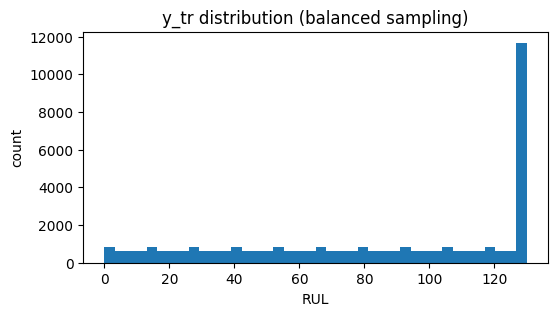

In [60]:
# =====================
# FIX v2) 학습 타깃(RUL)이 한 구간에 쏠려 "평균값만 찍는" 붕괴를 막기 위한 밸런스 샘플링
#  - (1) 엔진별 마지막 구간은 충분히 포함(고장 직전 패턴 학습)
#  - (2) 중/초반 구간도 일부 포함(큰 RUL 구간을 학습)
#  - (3) RUL_CAP 포화 구간(=RUL이 cap에 붙는 구간)은 과다대표를 줄임(다운샘플/가중치)
# =====================
from sklearn.model_selection import GroupShuffleSplit

def last_row_per_unit(df: pd.DataFrame) -> pd.DataFrame:
    return df.sort_values(index_cols).groupby("unit_number").tail(1)

# 1) 유닛 단위 split
units = np.array(sorted(train_fe["unit_number"].unique()))
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_u_idx, va_u_idx = next(gss.split(units, groups=units))
train_units = set(units[tr_u_idx])
val_units   = set(units[va_u_idx])

tr_rows_full = train_fe[train_fe["unit_number"].isin(train_units)].copy()
va_rows      = train_fe[train_fe["unit_number"].isin(val_units)].copy()

# 2) 엔진별 밸런스 샘플링
TAIL_N = 160                 # 마지막 N사이클은 항상 포함
MID_N  = 40                  # 중간 구간 랜덤 샘플 수
EARLY_N = 40                 # 초반 구간 랜덤 샘플 수
RNG = np.random.default_rng(42)

rows_list = []
for u, g in tr_rows_full.sort_values(index_cols).groupby("unit_number"):
    g = g.reset_index(drop=True)
    n = len(g)

    # tail
    tail = g.tail(min(TAIL_N, n))

    # early/mid: 구간을 나눠 랜덤 샘플
    #   early: 앞 40%
    #   mid  : 중간 40% (20%~60%)
    early_end = max(1, int(n * 0.4))
    mid_start = max(0, int(n * 0.2))
    mid_end   = max(mid_start + 1, int(n * 0.6))

    early_pool = g.iloc[:early_end]
    mid_pool   = g.iloc[mid_start:mid_end]

    def sample_df(pool, k):
        if len(pool) <= k:
            return pool
        idx = RNG.choice(len(pool), size=k, replace=False)
        return pool.iloc[idx]

    early = sample_df(early_pool, EARLY_N)
    mid   = sample_df(mid_pool, MID_N)

    rows_list.append(pd.concat([tail, mid, early], axis=0))

tr_rows = pd.concat(rows_list, axis=0).drop_duplicates().reset_index(drop=True)

# 3) 검증: last-cycle만 평가
va_last = last_row_per_unit(va_rows).copy()

# 4) X/y 구성
X_tr = tr_rows[kept_features].astype(float)
y_tr = tr_rows["RUL"].astype(float).values

X_va = va_last[kept_features].astype(float)
y_va = va_last["RUL"].astype(float).values

print("Train units:", len(train_units), " Val units:", len(val_units))
print("Train rows:", len(tr_rows), " Val last-cycle rows:", len(va_last))
print("y_tr range:", float(np.min(y_tr)), "~", float(np.max(y_tr)), " | mean:", float(np.mean(y_tr)))
print("y_va range:", float(np.min(y_va)), "~", float(np.max(y_va)), " | mean:", float(np.mean(y_va)))

# (진단) y 분포 확인: cap 포화가 심하면 붕괴 가능성이 커짐
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3))
plt.hist(y_tr, bins=40)
plt.title("y_tr distribution (balanced sampling)")
plt.xlabel("RUL"); plt.ylabel("count")
plt.show()


In [61]:
# =====================
# Step 11-추가) ✅ val_fe(검증 rows) 별칭 생성 + 랜덤 샘플용 seed
#   - 이 노트북의 split 결과: tr_rows_full / va_rows / va_last
#   - 아래부터는 va_rows를 val_fe라는 이름으로도 쓸 수 있게 맞춰둡니다.
# =====================
SEED = 42
val_fe = va_rows  # validation 전체 rows(엔진 단위 split된 부분)


In [62]:
# =====================
# Step 10) ✅ Cluster-based Multi-seed Modeling (CatBoost only)
#   - Global + Specific(0,1,3,4,6) 모델
# =====================
if CatBoostRegressor is None:
    raise ImportError("CatBoost가 필요합니다. `pip install catboost`")

SEEDS = [42, 2024, 777]
SPECIFIC_CLUSTERS = [0, 1, 3, 4, 6]

def make_catboost(seed: int):
    # 전략 문서의 '약식 튜닝' 컨셉: 노이즈에 덜 과민 + 과적합 억제
    return CatBoostRegressor(
        loss_function="RMSE",
        iterations=2500,
        depth=8,
        learning_rate=0.03,
        l2_leaf_reg=6.0,
        random_seed=seed,
        verbose=0,
        subsample=0.85,
        rsm=0.85,
    )

def train_models_for_seed(seed: int):
    models = {}
    # Global model (전체)
    gm = make_catboost(seed)
    gm.fit(X_tr, y_tr)
    models["global"] = gm

    # Specific models (조건별)
    for cid in SPECIFIC_CLUSTERS:
        sub_tr = tr_rows[tr_rows["condition_id"] == cid]
        if len(sub_tr) < 40:  # 데이터 부족 시 global로 대체
            continue
        Xm = sub_tr[kept_features].astype(float)
        ym = sub_tr["RUL"].astype(float).values
        m = make_catboost(seed)
        m.fit(Xm, ym)
        models[cid] = m
    return models

models_by_seed = {sd: train_models_for_seed(sd) for sd in SEEDS}
print("✅ trained seeds:", list(models_by_seed.keys()))
print("keys per seed:", {sd: list(models_by_seed[sd].keys()) for sd in SEEDS})


✅ trained seeds: [42, 2024, 777]
keys per seed: {42: ['global', 0, 1, 3, 4], 2024: ['global', 0, 1, 3, 4], 777: ['global', 0, 1, 3, 4]}


In [63]:
# =====================
# Step 13) ✅ Switching Inference (조건별 예측) -> Raw Prediction 생성
# =====================
def predict_switch(last_df: pd.DataFrame, X_last: pd.DataFrame) -> np.ndarray:
    preds = []
    cids = last_df["condition_id"].values.astype(int)

    for sd in SEEDS:
        models = models_by_seed[sd]
        p = np.zeros(len(last_df), dtype=float)
        for i, cid in enumerate(cids):
            if cid in models:
                p[i] = models[cid].predict(X_last.iloc[[i]])[0]
            else:
                p[i] = models["global"].predict(X_last.iloc[[i]])[0]
        preds.append(p)

    return np.mean(np.vstack(preds), axis=0)

raw_pred_va = predict_switch(va_last, X_va)
print("✅ raw_pred_va ready. RMSE:", rmse(y_va, raw_pred_va), "| NASA:", compute_nasa_score(y_va, raw_pred_va))


✅ raw_pred_va ready. RMSE: 9.650498933074665 | NASA: 90.80285362860397


In [64]:
# =====================
# Step 14) ✅ Post-process (안전한 최소 처리만)
#  - last-cycle 예측에서는 "유닛 간" smoothing을 하면 오히려 붕괴/왜곡이 생길 수 있어 제거
#  - 필요하면 (1) 0~RUL_CAP clipping 정도만 적용
#  - (선택) bias는 기본 OFF (0.0). 성능 확인 후 켜세요.
# =====================
BIAS_ADD = 0.0   # 기본 OFF
def postprocess_simple(pred, bias_add=0.0):
    out = np.asarray(pred, dtype=float) + float(bias_add)
    out = np.clip(out, 0.0, float(RUL_CAP))
    return out

pred_final = postprocess_simple(raw_pred_va, bias_add=BIAS_ADD)

print("RMSE raw     :", rmse(y_va, raw_pred_va), "| NASA raw     :", compute_nasa_score(y_va, raw_pred_va))
print("RMSE final   :", rmse(y_va, pred_final),  "| NASA final   :", compute_nasa_score(y_va, pred_final))


RMSE raw     : 9.650498933074665 | NASA raw     : 90.80285362860397
RMSE final   : 9.285277714877983 | NASA final   : 85.24895851034958


In [65]:
import numpy as np

BIAS_ADD = 0.0
FINAL_CLIP = 125.0

def postprocess(pred, unit_ids=None, bias_add=0.0, final_clip=125.0):
    pred = np.asarray(pred).reshape(-1).astype(float)
    pred = pred + float(bias_add)
    pred = np.clip(pred, 0.0, float(final_clip))
    return pred


In [66]:
# (안전장치) 커널 재시작/부분 실행 시 NameError 방지
import numpy as np
if "BIAS_ADD" not in globals(): BIAS_ADD = 0.0
if "FINAL_CLIP" not in globals(): FINAL_CLIP = 125.0
if "postprocess" not in globals():
    def postprocess(pred, unit_ids=None, bias_add=0.0, final_clip=125.0):
        pred = np.asarray(pred).reshape(-1).astype(float)
        pred = pred + float(bias_add)
        pred = np.clip(pred, 0.0, float(final_clip))
        return pred

# =====================
# Step 12) 테스트 데이터 생성(build_test_working) 개념 구현:
#   - 이 노트북에서는 test_fe 자체가 train과 동일 파이프라인을 거친 test_working 역할입니다.
#   - submission은 last-cycle(test_last)로 생성
# =====================
if test_fe is None:
    print("test 데이터가 없어 submission 파트를 건너뜁니다.")
else:
    test_last = last_row_per_unit(test_fe)
    X_test_last = test_last[kept_features].astype(float)
    raw_pred_te = predict_switch(test_last, X_test_last)
    pred_te = postprocess(raw_pred_te, test_last["unit_number"].astype(int).values, bias_add=BIAS_ADD, final_clip=FINAL_CLIP)

    sub = pd.DataFrame({
        "id": test_last["unit_number"].astype(int).values,
        "RUL": pred_te.astype(float)
    }).sort_values("id")

    sub.to_csv("submission.csv", index=False)
    print("✅ saved submission.csv", sub.shape)
    sub.head()


✅ saved submission.csv (259, 2)


## Step 15) ✅ 최종 평가 및 심층 분석 (문서 요구사항)

아래는 전략 문서 Step 15에 해당하는 **최종 평가/분석**입니다.

- **[분석 1] Unit별 기여도(Contribution)**: 어떤 엔진이 NASA 점수를 깎아먹는지
- **[분석 2] Bias 효과 확인**: raw → smoothed → biased 단계별로 NASA가 얼마나 개선되는지
- **최종 NASA Score 확인 (목표: 10,000 이하)**


In [67]:
# =====================
# Step 15-1) 단계별 점수 비교 테이블 (raw vs final)
# =====================
summary = pd.DataFrame([
    {"stage": "raw",   "rmse": rmse(y_va, raw_pred_va), "nasa": compute_nasa_score(y_va, raw_pred_va)},
    {"stage": "final", "rmse": rmse(y_va, pred_final),  "nasa": compute_nasa_score(y_va, pred_final)},
]).sort_values("nasa")
display(summary)

best_stage = summary.iloc[0]["stage"]
print("✅ Best stage by NASA:", best_stage)


,stage,rmse,nasa
1,final,9.285278,85.248959
0,raw,9.650499,90.802854


✅ Best stage by NASA: final


In [68]:
# =====================
# Step 15-2) Unit별 contribution 분석 (final 기준)
# =====================
df_val = va_last[["unit_number","condition_id","RUL"]].copy()
df_val["pred_raw"]   = raw_pred_va
df_val["pred_final"] = pred_final

df_val["residual_final"] = df_val["pred_final"] - df_val["RUL"]
df_val["nasa_contrib_final"] = nasa_contribution(df_val["RUL"].values, df_val["pred_final"].values)

df_val = df_val.sort_values("nasa_contrib_final", ascending=False)
display(df_val.head(30))

print("Total NASA (final):", float(df_val["nasa_contrib_final"].sum()))


,unit_number,condition_id,RUL,pred_raw,pred_final,residual_final,nasa_contrib_final
5079,26,3,0,31.713402,31.713402,31.713402,22.839413
31385,151,4,0,27.315965,27.315965,27.315965,14.357386
29473,143,0,0,21.230714,21.230714,21.230714,7.356765
44046,213,5,0,17.335481,17.335481,17.335481,4.660703
24659,120,5,0,16.341766,16.341766,16.341766,4.125236
3198,16,3,0,15.788464,15.788464,15.788464,3.849358
19795,98,4,0,15.357895,15.357895,15.357895,3.644991
18771,93,5,0,12.894406,12.894406,12.894406,2.630755
43850,212,3,0,12.862580,12.862580,12.862580,2.619218
20584,102,5,0,11.417634,11.417634,11.417634,2.132287


Total NASA (final): 85.24895851034958


In [69]:
# =====================
# Step 15-3) Cluster별 성능/기여도 요약 (final)
# =====================
g = df_val.groupby("condition_id").agg(
    n_units=("unit_number","nunique"),
    mean_true=("RUL","mean"),
    mean_pred=("pred_final","mean"),
    nasa_sum=("nasa_contrib_final","sum"),
    rmse=("residual_final", lambda s: float(np.sqrt(np.mean(s**2))))
).sort_values("nasa_sum", ascending=False)

display(g)


,n_units,mean_true,mean_pred,nasa_sum,rmse
condition_id,,,,,
3,4,0.0,16.776718,30.270535,19.143679
5,30,0.0,4.205333,22.897565,6.475387
4,4,0.0,10.668465,18.002378,15.668654
0,5,0.0,6.953030,9.554294,10.658765
1,6,0.0,4.777550,4.198709,5.793648
2,3,0.0,0.939243,0.325478,1.626816


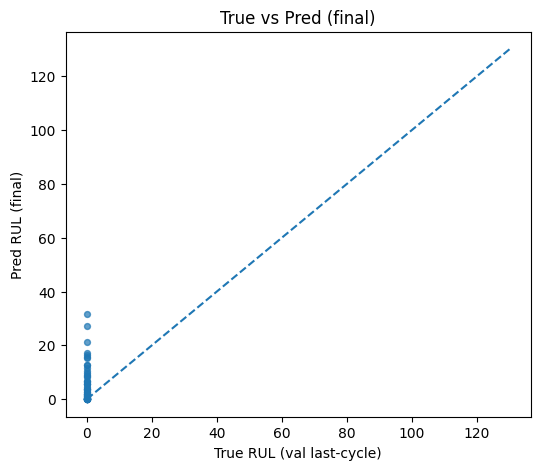

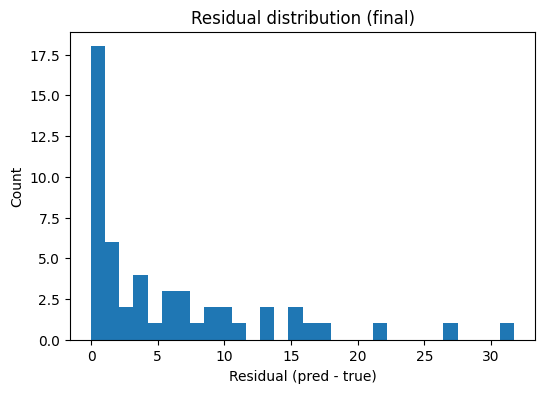

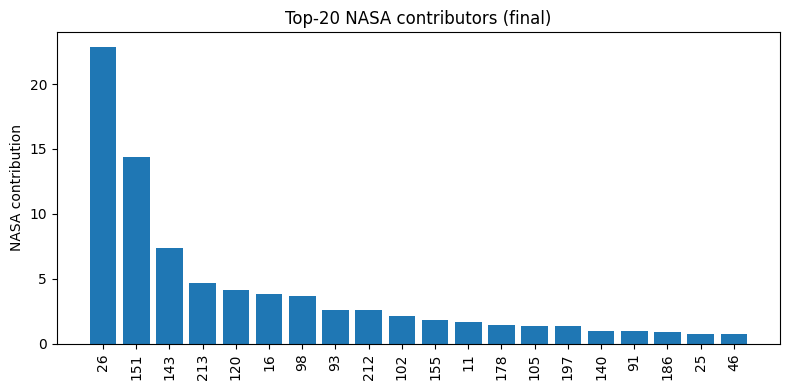

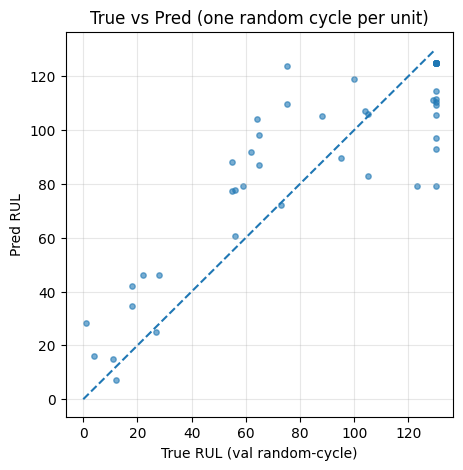

In [70]:
# =====================
# Step 15-4) 시각화: True vs Pred, residual 분포, 기여도 Top (final)
# =====================
import matplotlib.pyplot as plt

# scatter
plt.figure(figsize=(6,5))
plt.scatter(df_val["RUL"], df_val["pred_final"], s=18, alpha=0.7)
plt.plot([0, RUL_CAP], [0, RUL_CAP], linestyle="--")
plt.xlabel("True RUL (val last-cycle)")
plt.ylabel("Pred RUL (final)")
plt.title("True vs Pred (final)")
plt.show()

# residual hist
plt.figure(figsize=(6,4))
plt.hist(df_val["residual_final"], bins=30)
plt.xlabel("Residual (pred - true)")
plt.ylabel("Count")
plt.title("Residual distribution (final)")
plt.show()

# top contributors
topk = 20
plt.figure(figsize=(8,4))
plt.bar(df_val.head(topk)["unit_number"].astype(str), df_val.head(topk)["nasa_contrib_final"])
plt.xticks(rotation=90)
plt.ylabel("NASA contribution")
plt.title(f"Top-{topk} NASA contributors (final)")
plt.tight_layout()
plt.show()

def sample_one_row_per_unit(df, seed=42):
    return (df.groupby("unit_number", group_keys=False)
              .apply(lambda x: x.sample(1, random_state=seed)))

val_sample = sample_one_row_per_unit(val_fe, seed=42)

X_val_sample = val_sample[kept_features].astype(float)
pred_sample = postprocess(
    predict_switch(val_sample, X_val_sample),
    val_sample["unit_number"].astype(int).values,
    bias_add=BIAS_ADD,
    final_clip=FINAL_CLIP
)

plt.figure(figsize=(5,5))
plt.scatter(val_sample["RUL"].values, pred_sample, s=15, alpha=0.6)
mx = max(val_sample["RUL"].max(), pred_sample.max(), 1)
plt.plot([0, mx], [0, mx], "--")
plt.title("True vs Pred (one random cycle per unit)")
plt.xlabel("True RUL (val random-cycle)")
plt.ylabel("Pred RUL")
plt.grid(True, alpha=0.3)
plt.show()



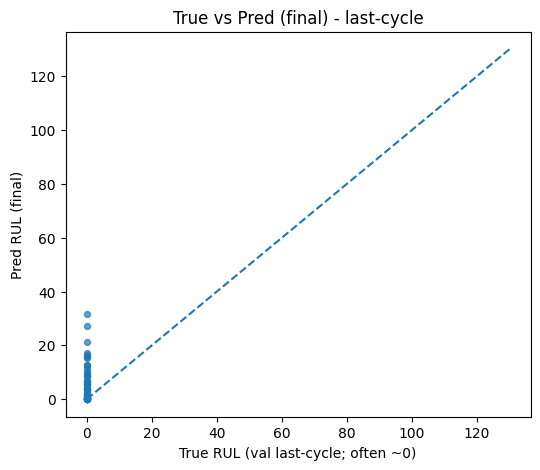

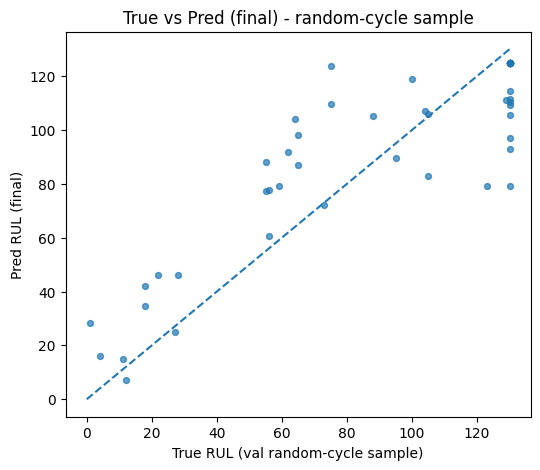

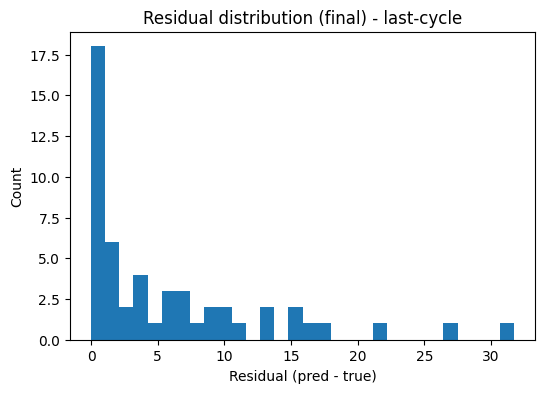

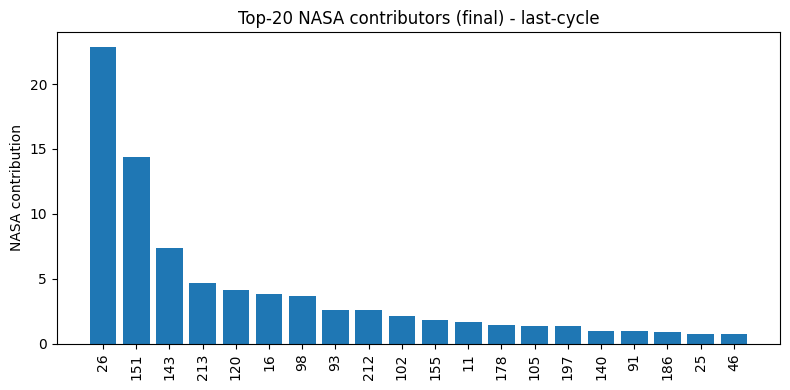

In [71]:
# =====================
# Step 15-4) 시각화: True vs Pred, residual 분포, 기여도 Top (final)
#   ⚠️ 참고: "last-cycle"의 True RUL은 (학습 데이터 기준) 거의 0이므로 True vs Pred가 세로줄처럼 보일 수 있습니다.
#   그래서 아래에 "랜덤 cycle 1개/유닛" 샘플로 True vs Pred도 함께 그립니다.
# =====================
import matplotlib.pyplot as plt
import numpy as np

# (A) last-cycle scatter (대부분 True=0이어서 세로줄처럼 보일 수 있음)
plt.figure(figsize=(6,5))
plt.scatter(df_val["RUL"], df_val["pred_final"], s=18, alpha=0.7)
plt.plot([0, RUL_CAP], [0, RUL_CAP], linestyle="--")
plt.xlabel("True RUL (val last-cycle; often ~0)")
plt.ylabel("Pred RUL (final)")
plt.title("True vs Pred (final) - last-cycle")
plt.show()

# (B) 랜덤 cycle 1개/유닛 샘플로 scatter (진짜 상관관계 확인용)
try:
    va_sample = val_fe.groupby("unit_number", group_keys=False).apply(lambda d: d.sample(1, random_state=SEED)).reset_index(drop=True)
    X_va_s = va_sample[kept_features].astype(float)
    raw_pred_s = predict_switch(va_sample, X_va_s)
    pred_s = postprocess(raw_pred_s, va_sample["unit_number"].astype(int).values, bias_add=BIAS_ADD, final_clip=FINAL_CLIP)
    plt.figure(figsize=(6,5))
    plt.scatter(va_sample["RUL"], pred_s, s=18, alpha=0.7)
    plt.plot([0, RUL_CAP], [0, RUL_CAP], linestyle="--")
    plt.xlabel("True RUL (val random-cycle sample)")
    plt.ylabel("Pred RUL (final)")
    plt.title("True vs Pred (final) - random-cycle sample")
    plt.show()
except Exception as e:
    print("random-cycle scatter skipped:", e)

# residual hist (last-cycle 기준)
plt.figure(figsize=(6,4))
plt.hist(df_val["residual_final"], bins=30)
plt.xlabel("Residual (pred - true)")
plt.ylabel("Count")
plt.title("Residual distribution (final) - last-cycle")
plt.show()

# top contributors
topk = 20
plt.figure(figsize=(8,4))
plt.bar(df_val.head(topk)["unit_number"].astype(str), df_val.head(topk)["nasa_contrib_final"])
plt.xticks(rotation=90)
plt.ylabel("NASA contribution")
plt.title(f"Top-{topk} NASA contributors (final) - last-cycle")
plt.tight_layout()
plt.show()


In [72]:
import pandas as pd
[k for k, v in globals().items() if isinstance(v, pd.DataFrame) and 'unit_number' in v.columns]


['_',
 '___',
 'train_raw',
 'test_raw',
 '_3',
 'train_sm',
 'test_sm',
 'train_cl',
 'test_cl',
 'train_df',
 'rul_last',
 'last_cycle',
 'test_df',
 '_6',
 'train_z',
 'test_z',
 'train_fe',
 'test_fe',
 'train_last',
 'tr_last',
 'va_last',
 'tr_rows_full',
 'va_rows',
 'tail',
 'early_pool',
 'mid_pool',
 'early',
 'mid',
 'tr_rows',
 'val_fe',
 'test_last',
 'df_val',
 'val_sample',
 'va_sample',
 'full_df',
 'test_full',
 '_40',
 '_51',
 '_54']

In [73]:
print("test_fe in globals?", "test_fe" in globals())
print("test_working in globals?", "test_working" in globals())
print("test_df in globals?", "test_df" in globals())


test_fe in globals? True
test_working in globals? False
test_df in globals? True


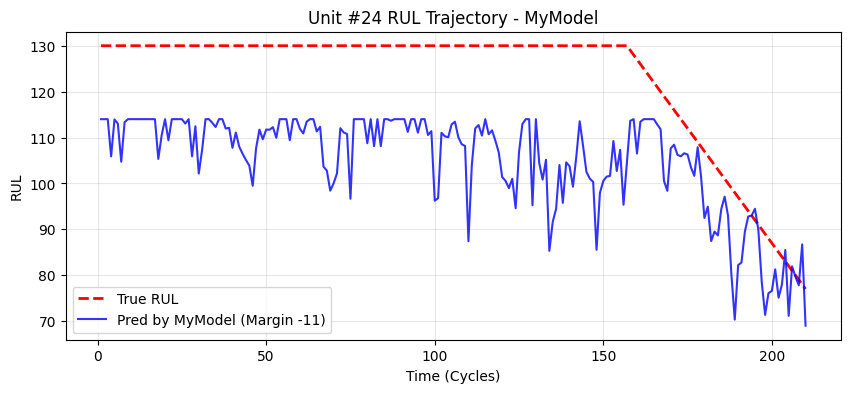

In [74]:
plot_engine_trajectory_v2_switch(
    model_name="MyModel",
    full_df=test_fe,      # ✅ 실제 변수명으로 교체
    unit_id=target_unit,
    feature_cols=kept_features,
    bias_add=BIAS_ADD,
    final_clip=FINAL_CLIP,
    safety_margin=11
)


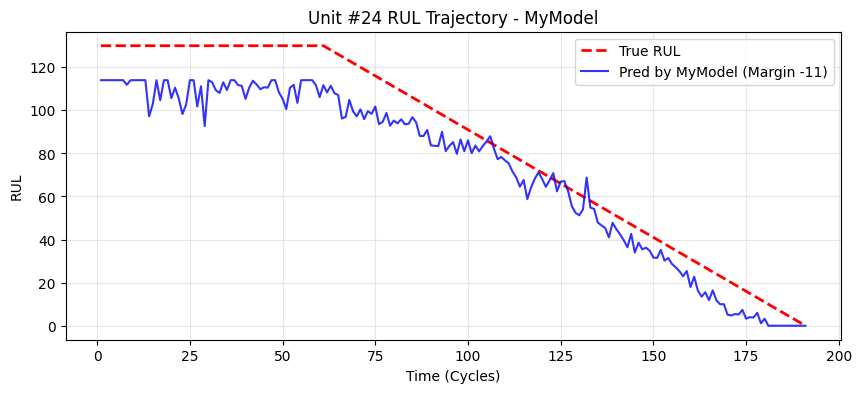

In [75]:
plot_engine_trajectory_v2_switch(
    model_name="MyModel",
    full_df=train_fe,     # 학습 데이터로 임시 확인
    unit_id=24,
    feature_cols=kept_features,
    bias_add=BIAS_ADD,
    final_clip=FINAL_CLIP,
    safety_margin=11
)


🎨 [Visualization v2-switch] Unit 24


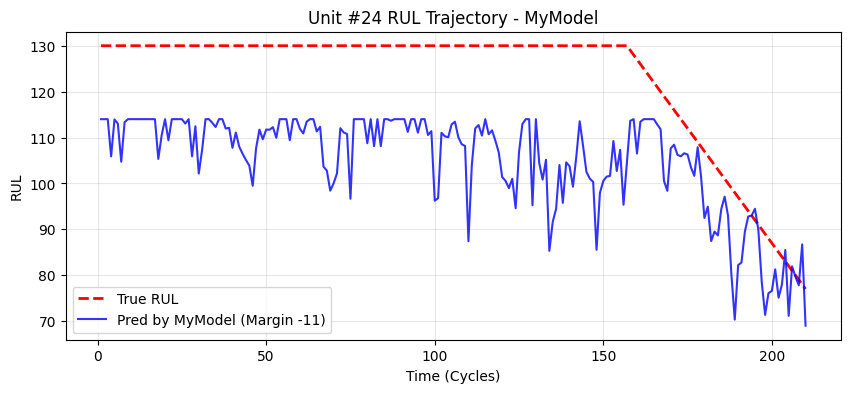

In [76]:
# === v2 Trajectory (predict_switch 기반) ===
def plot_engine_trajectory_v2_switch(model_name, full_df, unit_id, feature_cols,
                                     bias_add=0.0, final_clip=125.0, safety_margin=11):
    engine_data = full_df[full_df['unit_number'] == unit_id].copy()
    if len(engine_data) == 0:
        print(f"⚠️ Unit {unit_id} 데이터가 없습니다.")
        return

    X_engine = engine_data[feature_cols].astype(float)
    y_true = engine_data['RUL'].values.astype(float)

    # 예측 (노트북의 predict_switch 사용)
    raw_pred = predict_switch(engine_data, X_engine)
    y_pred = postprocess(
        raw_pred,
        engine_data["unit_number"].astype(int).values,
        bias_add=bias_add,
        final_clip=final_clip
    )

    # Safety Margin 적용
    y_pred = y_pred - float(safety_margin)
    y_pred = np.maximum(y_pred, 0.0)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 4))
    plt.plot(engine_data['time_in_cycles'], y_true, 'r--', label='True RUL', linewidth=2)
    plt.plot(engine_data['time_in_cycles'], y_pred, 'b-',
             label=f'Pred by {model_name} (Margin -{safety_margin})', alpha=0.8)
    plt.title(f"Unit #{unit_id} RUL Trajectory - {model_name}")
    plt.xlabel("Time (Cycles)")
    plt.ylabel("RUL")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# --- 실행 예시 (test_fe 사용) ---
target_unit = 24
print(f"🎨 [Visualization v2-switch] Unit {target_unit}")

# ✅ full_df 자동 선택: test_fe -> test_working -> test_df 순으로 찾기
if "test_fe" in globals() and test_fe is not None:
    full_df = test_fe
elif "test_working" in globals() and test_working is not None:
    full_df = test_working
elif "test_df" in globals() and test_df is not None:
    full_df = test_df
else:
    raise NameError("테스트 전처리 DF를 찾지 못했습니다. test_fe/test_working/test_df 중 하나가 필요합니다.")

plot_engine_trajectory_v2_switch(
    model_name="MyModel",
    full_df=full_df,              # ✅ 여기서 자동으로 test_fe 선택됨
    unit_id=target_unit,
    feature_cols=kept_features,
    bias_add=BIAS_ADD,
    final_clip=FINAL_CLIP,
    safety_margin=11
)


In [78]:
def nasa_score_phm08_per_engine(y_true, y_pred):
    """
    return:
      per_engine_scores: (N,) each engine score
      total_score: float sum
      mean_score: float mean
    """
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)
    d = y_pred - y_true
    per = np.where(d < 0, np.exp(-d / 13.0) - 1.0, np.exp(d / 10.0) - 1.0)
    return per, float(np.sum(per)), float(np.mean(per))

# ---- (기존) score 계산 부분을 아래로 교체 ----
per_scores, total_score, mean_score = nasa_score_phm08_per_engine(rul_gt, pred)

rmse = float(np.sqrt(np.mean((pred - rul_gt) ** 2)))
mae  = float(np.mean(np.abs(pred - rul_gt)))

print(f"📌 NASA Score TOTAL (sum over engines): {total_score:.4f}  (lower is better)")
print(f"📌 NASA Score MEAN  (per engine avg):   {mean_score:.4f}")
print(f"📌 RMSE (last-cycle): {rmse:.4f}")
print(f"📌 MAE  (last-cycle): {mae:.4f}")

# 엔진별 점수 테이블 (상위 벌점 엔진부터)
score_df = pd.DataFrame({
    "id": np.arange(1, len(rul_gt) + 1),
    "true_RUL": rul_gt,
    "pred_RUL": pred,
    "error(pred-true)": (pred - rul_gt),
    "nasa_score": per_scores
}).sort_values("nasa_score", ascending=False)

display(score_df.head(20))  # 벌점 큰 엔진 TOP 20


📌 NASA Score TOTAL (sum over engines): 21203.4525  (lower is better)
📌 NASA Score MEAN  (per engine avg):   81.8666
📌 RMSE (last-cycle): 32.0733
📌 MAE  (last-cycle): 23.6622


,id,true_RUL,pred_RUL,error(pred-true),nasa_score
85,86,194.0,87.699879,-106.300121,3556.923616
116,117,181.0,76.712387,-104.287613,3046.643909
255,256,191.0,88.743856,-102.256144,2605.744017
199,200,174.0,75.597381,-98.402619,1937.039644
197,198,32.0,102.135720,70.135720,1110.618157
124,125,179.0,89.627186,-89.372814,966.612618
165,166,188.0,99.000039,-88.999961,939.254737
169,170,182.0,93.623698,-88.376302,895.212072
243,244,181.0,94.843822,-86.156178,754.514013
202,203,192.0,107.693017,-84.306983,654.338910
